In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
custom_header = ['V', 'B', 'P', 'pl', 'H1', 'H2', 'SAS', 'FA']
df = pd.read_csv('aaProperties.txt', sep=';', index_col=0, header=None, decimal=',')
df.columns = custom_header

In [3]:
df.head(5)

,V,B,P,pl,H1,H2,SAS,FA
0,,,,,,,,
A,67,11.50,0.00,6.00,1.8,1.6,113,0.74
R,148,14.28,52.00,10.76,-4.5,-12.3,241,0.64
N,96,12.28,3.38,5.41,-3.5,-4.8,158,0.63
D,91,11.68,49.70,2.77,-3.5,-9.2,151,0.62
C,86,13.46,1.48,5.05,2.5,2.0,140,0.91


In [4]:
means = df.mean(axis=0)
std = df.std(axis=0)
df = (df - means) / std

In [5]:
df.head()
df.shape

(20, 8)

In [6]:
assert(np.allclose(df.mean(axis=0), 0.0))
assert(np.allclose(df.std(axis=0), 1.0))

Mamy ustandardowane dane

In [7]:
covariance_matrix = np.cov(df.T)
covariance_matrix

array([[ 1.        ,  0.72741358,  0.2358472 ,  0.37077128, -0.08022302,
        -0.15858483,  0.98694808,  0.18249961],
       [ 0.72741358,  1.        , -0.20220894,  0.08100402,  0.44390869,
         0.31852492,  0.63576635,  0.48621057],
       [ 0.2358472 , -0.20220894,  1.        ,  0.2737295 , -0.66875899,
        -0.85353202,  0.28832669, -0.52923834],
       [ 0.37077128,  0.08100402,  0.2737295 ,  1.        , -0.20338743,
        -0.26868408,  0.35651755, -0.17579864],
       [-0.08022302,  0.44390869, -0.66875899, -0.20338743,  1.        ,
         0.84952863, -0.18130107,  0.84097463],
       [-0.15858483,  0.31852492, -0.85353202, -0.26868408,  0.84952863,
         1.        , -0.22589954,  0.78756899],
       [ 0.98694808,  0.63576635,  0.28832669,  0.35651755, -0.18130107,
        -0.22589954,  1.        ,  0.12346638],
       [ 0.18249961,  0.48621057, -0.52923834, -0.17579864,  0.84097463,
         0.78756899,  0.12346638,  1.        ]])

In [8]:
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)
print(eigen_values)
eigen_vectors

[3.57289279e+00 2.81331163e+00 7.84551075e-01 4.26892356e-01
 2.78228871e-01 3.35430364e-03 4.65933157e-02 7.41756600e-02]


array([[-5.77917170e-02, -5.84887446e-01,  1.05908398e-01,
        -9.62082545e-02, -1.68693675e-01,  7.38856435e-01,
        -2.15311463e-01,  1.15623363e-01],
       [ 2.21464102e-01, -4.80941380e-01,  1.69146333e-01,
        -1.45311154e-01,  6.89638741e-01, -1.08982160e-01,
         3.47384727e-01, -2.48532442e-01],
       [-4.43534187e-01, -1.04052706e-01,  1.42504076e-01,
         7.33197524e-01,  1.61436004e-01, -1.04386126e-02,
        -2.29905261e-01, -3.94382380e-01],
       [-1.85432656e-01, -2.52649044e-01, -9.41826220e-01,
         2.70597776e-02,  5.33749852e-02, -3.03280668e-02,
         9.06639516e-02, -4.50077566e-02],
       [ 4.92907779e-01, -3.26764495e-02, -1.27905453e-01,
         3.54438938e-01,  3.42849243e-01, -6.65110520e-02,
        -4.94567465e-01,  4.97414419e-01],
       [ 5.07834603e-01,  3.35245081e-02, -1.28866135e-01,
        -1.32251326e-01, -1.85634034e-01,  1.85043820e-02,
        -4.05379234e-01, -7.12564733e-01],
       [-1.00406654e-01, -5.658099

In [9]:
sorted_indices = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_indices]
eigen_vectors = eigen_vectors[:, sorted_indices]

In [10]:
print(eigen_values)
eigen_vectors

[3.57289279e+00 2.81331163e+00 7.84551075e-01 4.26892356e-01
 2.78228871e-01 7.41756600e-02 4.65933157e-02 3.35430364e-03]


array([[-5.77917170e-02, -5.84887446e-01,  1.05908398e-01,
        -9.62082545e-02, -1.68693675e-01,  1.15623363e-01,
        -2.15311463e-01,  7.38856435e-01],
       [ 2.21464102e-01, -4.80941380e-01,  1.69146333e-01,
        -1.45311154e-01,  6.89638741e-01, -2.48532442e-01,
         3.47384727e-01, -1.08982160e-01],
       [-4.43534187e-01, -1.04052706e-01,  1.42504076e-01,
         7.33197524e-01,  1.61436004e-01, -3.94382380e-01,
        -2.29905261e-01, -1.04386126e-02],
       [-1.85432656e-01, -2.52649044e-01, -9.41826220e-01,
         2.70597776e-02,  5.33749852e-02, -4.50077566e-02,
         9.06639516e-02, -3.03280668e-02],
       [ 4.92907779e-01, -3.26764495e-02, -1.27905453e-01,
         3.54438938e-01,  3.42849243e-01,  4.97414419e-01,
        -4.94567465e-01, -6.65110520e-02],
       [ 5.07834603e-01,  3.35245081e-02, -1.28866135e-01,
        -1.32251326e-01, -1.85634034e-01, -7.12564733e-01,
        -4.05379234e-01,  1.85043820e-02],
       [-1.00406654e-01, -5.658099

In [11]:
ndim = 2
V_k = eigen_vectors[:, :ndim]
V_k

array([[-0.05779172, -0.58488745],
       [ 0.2214641 , -0.48094138],
       [-0.44353419, -0.10405271],
       [-0.18543266, -0.25264904],
       [ 0.49290778, -0.03267645],
       [ 0.5078346 ,  0.03352451],
       [-0.10040665, -0.56580992],
       [ 0.45339868, -0.17207863]])

In [12]:
X_reduced = np.dot(df, V_k)
X_reduced

array([[ 1.01908439,  2.09552586],
       [-3.7241217 , -2.24760244],
       [-1.08050038,  1.10756745],
       [-2.24018634,  1.50078863],
       [ 1.90901709,  1.03836161],
       [-1.0774753 ,  0.11286565],
       [-2.20531187,  0.47929201],
       [ 0.23320986,  3.72454273],
       [-1.51636004, -0.69217722],
       [ 2.36910921, -1.18157784],
       [ 2.11319113, -1.10017185],
       [-3.41477706, -1.39984845],
       [ 1.56155975, -0.81839556],
       [ 2.02401316, -1.5946514 ],
       [-0.01614268,  0.7629105 ],
       [ 0.04259448,  2.24944953],
       [ 0.48727579,  0.83743608],
       [ 0.97150262, -2.86499538],
       [ 0.25362203, -1.50959575],
       [ 2.29069587, -0.49972415]])

In [13]:
explained_variance_ratio = np.sum(eigen_values[:ndim]) / np.sum(eigen_values)
explained_variance_ratio

0.7982755522356413

Wyjaśniona wariancja na poziomie +- 80%, co świadczy o tym, że otrzymane dane są reprezentatywne

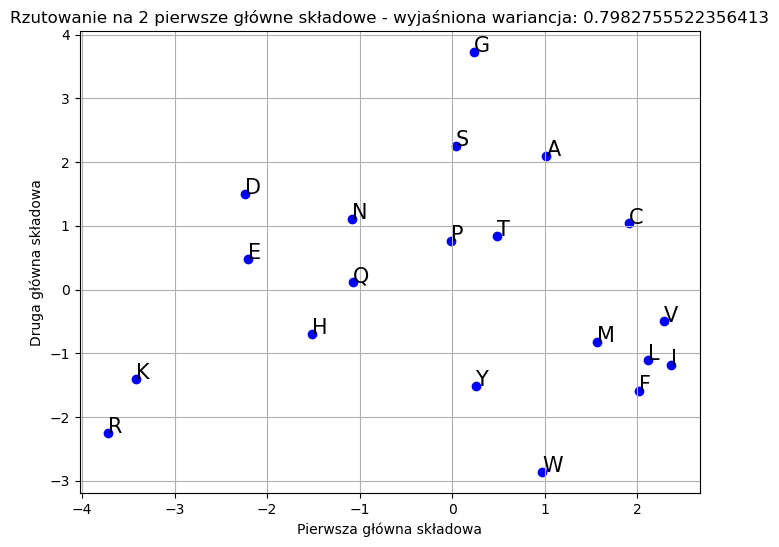

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c='blue', marker='o')
for i, label in enumerate(df.index):
    plt.text(X_reduced[i, 0], X_reduced[i, 1], label, fontsize=15)
plt.title('Rzutowanie na 2 pierwsze główne składowe - wyjaśniona wariancja: {}'.format(explained_variance_ratio))
plt.xlabel('Pierwsza główna składowa')
plt.ylabel('Druga główna składowa')
plt.grid(True)
plt.show()

Aminokwasy bliskie sobie w przestrzeni (na wykresie) mają podobne właściwości, co może sugerować, że mają one podobne wartości w oryginalnych dominujących zmiennych - czyli tutaj np M, L, V, I, F mają podobne wartości w oryginalnych dominujących zmiennych (są to aminokwasy hydrofobowe, co zgodnie z interpretacją PC1, odzwierciedla ich podobieństwo w wartościach H2, H1, oraz FA).
Aminokwasy oddalone od siebie mają różnice w tych właściwościach.
Aminokwasy takie jak G i A znajdują się bliżej centrum wykresu, co sugeruje, że ich właściwości są bardziej neutralne w stosunku do dominujących składowych.

In [15]:
print("Współczynniki wektora własnego dla PC1:")
for i, var in enumerate(df.columns):
    print(f"{var}: {eigen_vectors[i, 0]}")

Współczynniki wektora własnego dla PC1:
V: -0.05779171697488691
B: 0.22146410234001201
P: -0.44353418704522185
pl: -0.18543265581121948
H1: 0.4929077787733335
H2: 0.5078346029821154
SAS: -0.10040665424636885
FA: 0.45339868253728455


Dla PC1 dominujące zmienne to H2, H1, FA (największe wartości bezwzględne)

In [16]:
print("Współczynniki wektora własnego dla PC2:")
for i, var in enumerate(df.columns):
    print(f"{var}: {eigen_vectors[i, 1]}")

Współczynniki wektora własnego dla PC2:
V: -0.5848874462524827
B: -0.48094137980622564
P: -0.10405270624314447
pl: -0.2526490439915138
H1: -0.03267644953253749
H2: 0.03352450814382012
SAS: -0.565809916239367
FA: -0.1720786302387599


Dla PC2 dominujące zmienne to V, SAS, B (największe wartości bezwzględne)

Dla przykładu weźmy parę będącą blisko siebie względem zarówno PC1 i PC2 - L i I

In [17]:
df.loc[['L', 'I']]

,V,B,P,pl,H1,H2,SAS,FA
0,,,,,,,,
L,0.509545,1.303153,-0.6144,-0.026283,1.436237,0.852243,0.102942,0.984257
I,0.509545,1.303153,-0.6144,-0.003674,1.670588,0.913556,0.147699,1.244414


Zarówno na dominujących składowych dla PC1 (H2, H1, FA), jak i dla PC2 (V, SAS, B) wartości są bliskie siebie

Teraz przykład, gdzie są blisko siebie w zależności od PC1, daleko w zależności od PC2

In [18]:
df.loc[['G', 'Y']]

,V,B,P,pl,H1,H2,SAS,FA
0,,,,,,,,
G,-2.107038,-2.567918,-0.620332,-0.031936,0.030131,0.484368,-2.023035,-0.143086
Y,1.094833,0.578403,-0.546863,-0.207157,-0.271178,0.136931,1.199499,0.203789


Dla H2, H1, FA wartości bliskie - stąd blisko siebie względem PC1 (różnice max 0.3)
Dla V, SAS, B wartości względnie odległe od siebie - stąd duża odległość względem PC2 (różnice około 3.0)

Dla odległych względem obu zmiennych:

In [19]:
df.loc[['G', 'R']]

,V,B,P,pl,H1,H2,SAS,FA
0,,,,,,,,
G,-2.107038,-2.567918,-0.620332,-0.031936,0.030131,0.484368,-2.023035,-0.143086
R,1.335834,-0.228071,1.752572,2.675518,-1.342497,-2.233817,1.468043,-0.836836


Dla H2, H1, FA, V, SAS, B czyli dla zmiennych dominujących różnice są stosunkowo duże

Na podstawie analizy położenia aminokwasów na wykresie widzimy zależności między wartościami poszczególnych ich zmiennych.
